# IMPORT LIBRARIES

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from matplotlib.dates import DateFormatter
from scipy.optimize import minimize # USE IN THE MODEL CALIBRATION

from google.colab import files
import zipfile
import os

In [2]:
from google.colab import drive

# Monter Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


##CAMELS-DATA from my Google Drive.

In [3]:
# ==============================
# Paths to ZIP files
# ==============================
hydro_zip = "/content/drive/MyDrive/Colab Notebooks/Dimension/05_hydrometeorology.zip"
streamflow_zip = "/content/drive/MyDrive/Colab Notebooks/Dimension/03_streamflow.zip"

# Data extraction directories
hydro_dir = "/content/05_hydro"
streamflow_dir = "/content/03_streamflow"

# ==============================
# Function to extract ZIP files
# ==============================
def extract_zip(zip_path, extract_to):
    if not os.path.exists(extract_to):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print(f"✅ ZIP extracted in {extract_to}")
    else:
        print(f"✅ Directory {extract_to} already exists")

def find_csv(base_dir, csv_name):
    # Recursive search for the CSV file
    for root, dirs, files in os.walk(base_dir):
        if csv_name in files:
            return os.path.join(root, csv_name)
    raise FileNotFoundError(f"{csv_name} not found in {base_dir}")

# ==============================
# Extraction
# ==============================
extract_zip(hydro_zip, hydro_dir)
extract_zip(streamflow_zip, streamflow_dir)

# ==============================
# Load the 222 basins data
# ==============================
file_path = '/content/drive/MyDrive/Colab Notebooks/Dimension/id_name_metadata.csv'
basin222 = pd.read_csv(file_path)
station_ids_v1 = basin222['station_id'].astype(str).str.strip().unique()
print(f"✅ {len(station_ids_v1)} official basins loaded")

# ==============================
# 1️⃣ Precipitation (SILO)
# ==============================
precip_file = find_csv(hydro_dir, "precipitation_SILO.csv")
precip = pd.read_csv(precip_file, index_col=0, parse_dates=True)
precip.columns = precip.columns.str.strip()
precip.replace(-99.99, np.nan, inplace=True)
print("✅ SILO precipitation:", precip.shape)

# ==============================
# 2️⃣ Evapotranspiration (ET SILO)
# ==============================
et_file = find_csv(hydro_dir, "et_morton_actual_SILO.csv")
et = pd.read_csv(et_file, index_col=0, parse_dates=True)
et.columns = et.columns.str.strip()
et.replace(-99.99, np.nan, inplace=True)
print("✅ SILO ET:", et.shape)

# ==============================
# 3️⃣ Streamflow
# ==============================
streamflow_file = find_csv(streamflow_dir, "streamflow_mmd.csv")
Q = pd.read_csv(streamflow_file, index_col=0, parse_dates=True)
Q.columns = Q.columns.str.strip()
Q.replace(-99.99, np.nan, inplace=True)
print("✅ Streamflow:", Q.shape)

# ==============================
# 4️⃣ Identify common stations
# ==============================
stations_precip = set(precip.columns)
stations_et = set(et.columns)
stations_Q = set(Q.columns)

common_stations = [
    s for s in station_ids_v1
    if s in stations_precip and s in stations_et and s in stations_Q
]

print(f"✅ Official common stations: {len(common_stations)}")

# ==============================
# 5️⃣ Subset common stations
# ==============================
precip = precip[common_stations]
et = et[common_stations]
Q = Q[common_stations]

# ==============================
# 6️⃣ Final verification
# ==============================
print("Precipitation:", precip.shape)
print("ET:", et.shape)
print("Streamflow:", Q.shape)
print("Stations (first 10):", common_stations[:10], "...")


✅ ZIP extracted in /content/05_hydro
✅ ZIP extracted in /content/03_streamflow
✅ 222 official basins loaded
✅ SILO precipitation: (43464, 224)
✅ SILO ET: (43464, 224)
✅ Streamflow: (23376, 224)
✅ Official common stations: 222
Precipitation: (43464, 222)
ET: (43464, 222)
Streamflow: (23376, 222)
Stations (first 10): ['912101A', '912105A', '915011A', '917107A', '919003A', '919201A', '919309A', '922101B', '925001A', '926002A'] ...


In [4]:
# Verification of the periods
print("Precipitation :", precip.index.min(), "→", precip.index.max())
print("ET            :", et.index.min(), "→", et.index.max())
print("Streamflow    :", Q.index.min(), "→", Q.index.max())


Precipitation : 1900-01-01 00:00:00 → 2018-01-01 00:00:00
ET            : 1900-01-01 00:00:00 → 2018-01-01 00:00:00
Streamflow    : 1951-01-01 00:00:00 → 2014-01-01 00:00:00


In [5]:
# ==============================
# 0️⃣ Reduce all series to the period 1 January 1980 → 31 December 2014
# ==============================
start_date = "1980-01-01"
end_date   = "2014-12-31"

precip = precip.loc[start_date:end_date]
et     = et.loc[start_date:end_date]
Q      = Q.loc[start_date:end_date]

# Verification
print("Common period verification:")
print("Precipitation :", precip.index.min(), "→", precip.index.max())
print("ET            :", et.index.min(), "→", et.index.max())
print("Streamflow    :", Q.index.min(), "→", Q.index.max())

Common period verification:
Precipitation : 1980-01-01 00:00:00 → 2014-01-01 00:00:00
ET            : 1980-01-01 00:00:00 → 2014-01-01 00:00:00
Streamflow    : 1980-01-01 00:00:00 → 2014-01-01 00:00:00


#High RR identification

In [6]:
import numpy as np

# =============================================================
# 📌 COMPUTE RR
# =============================================================
RR = []
stations_list = []

start_date = "1980-01-01"
end_date = "2014-12-31"

for st in common_stations:
    P = precip[st].loc[start_date:end_date].to_numpy(float)
    Qs = Q[st].loc[start_date:end_date].to_numpy(float)

    mask = (~np.isnan(P)) & (~np.isnan(Qs))

    if mask.sum() == 0 or np.nansum(P[mask]) <= 0:
        RR.append(np.nan)
    else:
        RR.append(np.nansum(Qs[mask]) / np.nansum(P[mask]))

    stations_list.append(st)

RR = np.array(RR)
stations = np.array(stations_list)

# =============================================================
# 📌 CLEAN
# =============================================================
mask = np.isfinite(RR)
RR = RR[mask]
stations = stations[mask]

# =============================================================
# 📌 PERCENTILES
# =============================================================
p10 = np.percentile(RR, 10)
p50 = np.percentile(RR, 50)
p60 = np.percentile(RR, 60)
p90 = np.percentile(RR, 90)

# =============================================================
# 📌 SELECT CLASSES
# =============================================================
dry_mask = RR <= p10
mid_mask = (RR >= p50) & (RR <= p60)
wet_mask = RR >= p90

dry_stations_all = stations[dry_mask]
mid_stations_all = stations[mid_mask]
wet_stations_all = stations[wet_mask]

dry_RR_all = RR[dry_mask]
mid_RR_all = RR[mid_mask]
wet_RR_all = RR[wet_mask]

# =============================================================
# 📌 SORT INSIDE EACH CLASS (IMPORTANT)
# =============================================================
def sort_pair(st, rr):
    order = np.argsort(rr)
    return st[order], rr[order]

dry_stations_all, dry_RR_all = sort_pair(dry_stations_all, dry_RR_all)
mid_stations_all, mid_RR_all = sort_pair(mid_stations_all, mid_RR_all)
wet_stations_all, wet_RR_all = sort_pair(wet_stations_all, wet_RR_all)

# =============================================================
# 📌 FIXED SIZE SAMPLING
# =============================================================
dry_n = 23
mid_n = 22
wet_n = 22

assert len(dry_stations_all) >= dry_n, "Not enough dry basins"
assert len(mid_stations_all) >= mid_n, "Not enough mid basins"
assert len(wet_stations_all) >= wet_n, "Not enough wet basins"

dry_stations = dry_stations_all[:dry_n]
dry_RR = dry_RR_all[:dry_n]

mid_stations = mid_stations_all[:mid_n]
mid_RR = mid_RR_all[:mid_n]

wet_stations = wet_stations_all[:wet_n]
wet_RR = wet_RR_all[:wet_n]

# =============================================================
# 📌 FINAL CHECK
# =============================================================
print("🟤 Dry:", len(dry_stations))
print("🟡 Mid:", len(mid_stations))
print("🔵 Wet:", len(wet_stations))

# =============================================================
# 📌 OUTPUT
# =============================================================
RR_classes = {
    "dry_0_10": {"stations": dry_stations, "RR": dry_RR},
    "mid_50_60": {"stations": mid_stations, "RR": mid_RR},
    "wet_90_100": {"stations": wet_stations, "RR": wet_RR},
}

🟤 Dry: 23
🟡 Mid: 22
🔵 Wet: 22


In [7]:
# =============================================================
# 📌 DISPLAY RR RANGES
# =============================================================
def print_range(name, rr_values):
    print(f"{name} RR range: [{np.min(rr_values):.4f} , {np.max(rr_values):.4f}]")

print("\n===== RR RANGES =====")
print_range("🟤 Dry (0–10%)", dry_RR)
print_range("🟡 Mid (50–60%)", mid_RR)
print_range("🔵 Wet (90–100%)", wet_RR)


===== RR RANGES =====
🟤 Dry (0–10%) RR range: [0.0060 , 0.0659]
🟡 Mid (50–60%) RR range: [0.1838 , 0.2306]
🔵 Wet (90–100%) RR range: [0.4444 , 0.7955]


In [8]:
print(type(dry_stations), dry_stations[:3])
print(type(mid_stations), mid_stations[:3])
print(type(wet_stations), wet_stations[-10:])

<class 'numpy.ndarray'> ['616002' '616013' 'A2390523']
<class 'numpy.ndarray'> ['G8110016' 'A5040523' '212260']
<class 'numpy.ndarray'> ['112102A' '304497' '112002A' '312061' '315450' '108003A' '308145'
 '225020A' '308799' '113004A']


GRHyMoLAP

In [104]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from numba import njit

# ============================================
# PARAMETERS
# ============================================
start_date = "1980-01-01"
end_date = "2014-12-31"
b1_ratio = 0.7
max_missing_ratio = 1

stations = ['113004A']

results_GRHyMoLAP = {}


# ============================================
# NSE
# ============================================
def NSE(obs, sim):
        df = pd.DataFrame({"obs": obs, "sim": sim}).dropna()
        if df.empty or df["obs"].var() == 0:
            return np.nan
        return 1 - np.sum((df["sim"] - df["obs"])**2) / np.sum((df["obs"] - df["obs"].mean())**2)


# ============================================
# PERCOLATION
# ============================================


def Percolation(Pn, En, X1):
        n = len(Pn)
        S = np.zeros(n)
        S[0] = X1/2
        Perc = np.zeros(n)
        ratio = (4.0 / 9.0) * (S[0] / X1)
        Perc[0] = S[0] * (1 - (1 + ratio**4) ** (-0.25))
        for i in range(1, n):
            temp = (S[i-1] / X1) ** 2
            frac = Pn[i] / X1
            Ps = X1 * (1 - temp) * np.tanh(frac) / (1 + (S[i-1] / X1) * np.tanh(frac))
            frac = En[i] / X1
            Es = S[i-1] * (2 - S[i-1]/X1) * np.tanh(frac) / (1 + (1 - S[i-1]/X1) * np.tanh(frac))
            S[i] = S[i-1] + Ps - Es
            ratio = (4.0 / 9.0) * (S[i] / X1)
            Perc[i] = S[i] * (1 - (1 + ratio**4) ** (-0.25))
            S[i] = S[i] - Perc[i]
        return Perc


# ============================================
# MODEL
# ============================================


# ============================================
# GRHyMoLAP model
# ============================================
def GRHyMoLAP_Model(params, Q0, Pn, En):
        MU, LAMBDA, X1, gamma = params
        N = len(Pn)
        Q = np.zeros(N)
        Q[0] = Q0
        Perc = Percolation(Pn, En, X1)
        for t in range(N-1):
            Q[t+1] = max(0, Q[t] - (MU / LAMBDA) * (Q[t])**(2*MU - 1) + gamma * Perc[t+1] * Pn[t+1])
        return Q


# ============================================
# OBJECTIVE
# ============================================

def objective(params, Q0, Pn_train, En_train, Q_obs_train):
    Q_sim = GRHyMoLAP_Model(params, Q0, Pn_train, En_train)
    nse = NSE(Q_obs_train, Q_sim)
    return 1 - nse if np.isfinite(nse) else 1e9


# ============================================
# MAIN LOOP (2 BASINS ONLY)
# ============================================

for i, station_id in enumerate(stations, start=1):


    print(f"\n=== Station {station_id} ===")

    Q_obs = Q[station_id].loc[start_date:end_date].to_numpy(float)
    P = precip[station_id].loc[start_date:end_date].to_numpy(float)
    PET = et[station_id].loc[start_date:end_date].to_numpy(float)

    Pn = np.maximum(0, P - PET)
    En = np.maximum(0, PET - P)

    N = len(Q_obs)
    missing_ratio = np.sum(np.isnan(Q_obs)) / N

    if N == 0 or missing_ratio > max_missing_ratio:
        continue

    b1 = int(N * b1_ratio)
    Q0 = Q_obs[0]

    # ============================================
    # CALIBRATION
    # ============================================

    initial_guesses = [
        [1.0, 8, 150, 0.1],
        [0.6, 2, 120, 1],
        [1.4, 15, 200, 0.5]
    ]

    best_val = float("inf")
    best_res = None

    for guess in initial_guesses:
        res = minimize(
            objective,
            guess,
            args=(Q0, Pn[:b1], En[:b1], Q_obs[:b1]),
            method="Nelder-Mead",
            options={'maxiter': 2500, 'disp': False}
        )
        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    params = best_res.x

    Qsim = GRHyMoLAP_Model(params, Q0, Pn, En)

    NSE_cal = 1 - best_res.fun
    NSE_val = NSE(Q_obs[b1:], Qsim[b1:])

    print(f"✅ NSE cal: {NSE_cal:.3f} | NSE val: {NSE_val:.3f}")


    # ============================================
    # STORE RESULTS
    # ============================================

    results_GRHyMoLAP[station_id] = {
        "params": params,
        "NSE_cal": NSE_cal,
        "NSE_val": NSE_val,
        "Qsim": Qsim
    }

print("\n✅ Completed.")


=== Station 113004A ===
✅ NSE cal: 0.867 | NSE val: 0.831

✅ Completed.


##Input term pertubation

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

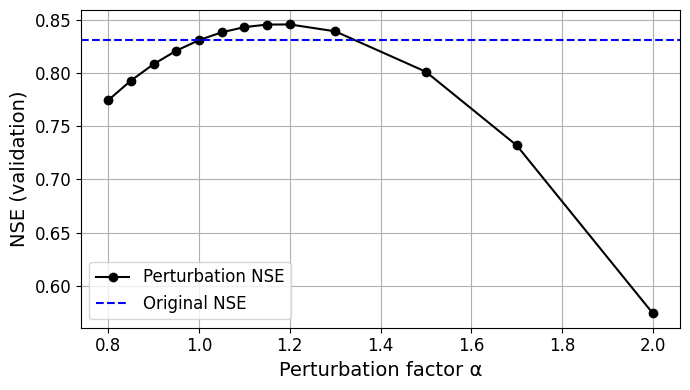

In [139]:
# ============================================
# CONDITIONAL PERTURBATION ON MODEL INPUT
# ============================================

def GRHyMoLAP_Perturbed_input_threshold(params, Q0, Pn, En, alpha, perc_thresh=0.9):
    """
    Apply a multiplicative perturbation alpha only on the input term (Perc * Pn)
    if its value exceeds the specified percentile threshold.
    """
    MU, LAMBDA, X1, GAMMA = params
    N = len(Pn)
    Q = np.zeros(N)
    Q[0] = Q0

    # Compute percolation
    Perc = Percolation(Pn, En, X1)

    # Combined model input term
    Input = Perc * Pn

    # Compute percentile threshold
    thresh = np.percentile(Input, perc_thresh*100)

    # Apply alpha only for values above the threshold
    Input_pert = Input.copy()
    Input_pert[Input > thresh] *= alpha

    # Model simulation
    for t in range(N-1):
        Q[t+1] = Q[t] - (MU / LAMBDA) * Q[t]**(2*MU - 1) + GAMMA * Input_pert[t+1]
        if Q[t+1] < 0:
            Q[t+1] = 0.0
    return Q

# ============================================
# SWEEP ALPHA
# ============================================

alpha_list = np.concatenate([np.arange(0.8, 1.21, 0.05), [1.3, 1.5, 1.7, 2.0]])

station_id = stations[0]
Q0 = Q_obs[0]

NSE_sweep = []

for alpha in alpha_list:
    # Simulate with perturbed input above the threshold
    Qsim = GRHyMoLAP_Perturbed_input_threshold(
        results_GRHyMoLAP[station_id]['params'], Q0, Pn, En, alpha, perc_thresh=0.8
    )
    # Compute NSE for the validation period
    NSE_sweep.append(NSE(Q_obs[b1:], Qsim[b1:]))

# ============================================
# FINAL PLOT
# ============================================

plt.figure(figsize=(7,4))  # slightly larger
plt.plot(alpha_list, NSE_sweep, marker='o', label='Perturbation NSE', color='black')
plt.axhline(y=results_GRHyMoLAP[station_id]['NSE_val'], color='blue', linestyle='--', label='Original NSE')

# Axes and labels with larger fontsize
plt.xlabel('Perturbation factor α', fontsize=14)
plt.ylabel('NSE (validation)', fontsize=14)

# Increase tick label size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Make legend more readable
plt.legend(fontsize=12)

plt.grid(True)
plt.tight_layout()
plt.savefig("robust1.jpeg", dpi=700)
files.download("robust1.jpeg")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

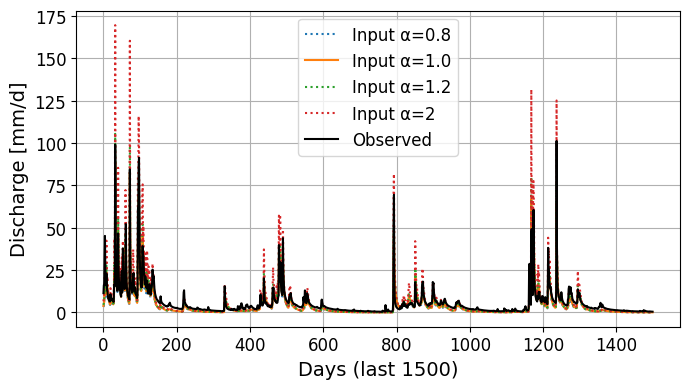

In [136]:
# ============================================
# LAST N_LAST DAYS PLOT FOR CONDITIONAL INPUT PERTURBATION
# ============================================

N_last = 1500
Q_obs_last = Q_obs[-N_last:]

# Alpha values to plot (including 1 for reference)
alpha_plot = [0.8, 1.0, 1.2, 2]

# ============================================
# Figure: 1x1 (could be 1x2 if needed)
# ============================================
fig, ax = plt.subplots(1, 1, figsize=(7,4))  # slightly wider

for alpha in alpha_plot:
    # Simulate with conditional perturbation on input (Perc * Pn)
    Qsim = GRHyMoLAP_Perturbed_input_threshold(
        results_GRHyMoLAP[station_id]['params'], Q0, Pn, En, alpha, perc_thresh=0.8
    )
    linestyle = ':' if alpha != 1 else '-'  # solid line for reference
    ax.plot(Qsim[-N_last:], label=f'Input α={alpha}', linestyle=linestyle)

# Plot observed discharge
ax.plot(Q_obs_last, color='black', linestyle = '-', linewidth=1.5, label='Observed')

# Labels with fontsize
ax.set_xlabel(f'Days (last {N_last})', fontsize=14)
ax.set_ylabel('Discharge [mm/d]', fontsize=14)

# Larger ticks
ax.tick_params(axis='both', which='major', labelsize=12)

# More readable legend
ax.legend(fontsize=12)

# Optional: grid
ax.grid(True)

plt.tight_layout()
plt.savefig("robust2.jpeg", dpi=700)
files.download("robust2.jpeg")
plt.show()